# Part 1: Selecting the Target Variable

In this section, we will identify the target variable for our analysis. The target variable is the feature we want to predict or analyze based on the other features in the dataset. For our **Top 1000 Movies from IMDb** dataset, we will select `IMDB_Rating` as our target variable, as it represents the overall rating of the movies and is a key metric for evaluating their success and popularity.

# Part 2: Feature Selection & Engineering

## Importing Libraries
In this section, we import essential libraries that will help us explore and analyze the dataset.


In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

## Loading the Dataset

Let's load the **Top 1000 Movies from IMDb** dataset. Since it's stored online, we use `pd.read_csv()` to read it directly from the URL.

In [2]:
url = "https://raw.githubusercontent.com/krishna-koly/IMDB_TOP_1000/refs/heads/main/imdb_top_1000.csv"
df = pd.read_csv(url)
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  1000 non-null   str    
 3   Certificate    899 non-null    str    
 4   Runtime        1000 non-null   str    
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   str    
 10  Star1          1000 non-null   str    
 11  Star2          1000 non-null   str    
 12  Star3          1000 non-null   str    
 13  Star4          1000 non-null   str    
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    str    
dtypes: float64(2), int64(1), str(13)
memory usage: 519.7 KB
None
                                         Poster

## Data Preprocessing
Same as last time, we will handle missing values and then build a corelation matrix to understand the relationships between different features in the dataset.

In [3]:
df["Certificate"] = df["Certificate"].fillna("Not Rated")

df["Meta_score"] = df["Meta_score"].fillna(df["Meta_score"].median())

df['Gross'] = df['Gross'].str.replace(',', '', regex=False)
df['Gross'] = pd.to_numeric(df['Gross'], errors='coerce')
median_gross = df['Gross'].median()
df['Gross'] = df['Gross'].fillna(median_gross)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Poster_Link      0
Series_Title     0
Released_Year    0
Certificate      0
Runtime          0
Genre            0
IMDB_Rating      0
Overview         0
Meta_score       0
Director         0
Star1            0
Star2            0
Star3            0
Star4            0
No_of_Votes      0
Gross            0
dtype: int64


### Fixing Data Inconsistencies

Runtime column has " min" text that needs to be removed before converting it to numeric. Also, we will convert the 'Released_Year' to numeric type for better analysis.

In [4]:
df['Runtime'] = df['Runtime'].str.replace(' min', '', regex=False)
df['Runtime'] = pd.to_numeric(df['Runtime'], errors='coerce')

df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

print("Data types after cleaning:")
print(df.dtypes)

Data types after cleaning:
Poster_Link          str
Series_Title         str
Released_Year    float64
Certificate          str
Runtime            int64
Genre                str
IMDB_Rating      float64
Overview             str
Meta_score       float64
Director             str
Star1                str
Star2                str
Star3                str
Star4                str
No_of_Votes        int64
Gross            float64
dtype: object


### Normalization
To ensure that the features are on a similar scale, we will normalize the 'IMDB_Rating' and 'Meta_score' columns using Min-Max Scaling.

In [5]:
scaler = MinMaxScaler()
df[['IMDB_Rating', 'Meta_score']] = scaler.fit_transform(df[['IMDB_Rating', 'Meta_score']])

print("Normalized ratings:")
print(df[['IMDB_Rating', 'Meta_score']].describe())

Normalized ratings:
       IMDB_Rating   Meta_score
count  1000.000000  1000.000000
mean      0.205471     0.696292
std       0.162054     0.157892
min       0.000000     0.000000
25%       0.058824     0.611111
50%       0.176471     0.708333
75%       0.294118     0.795139
max       1.000000     1.000000


### Encoding Categorical Variables
We want to convert the `Star` column, which contains multiple actors, into a format suitable for analysis, also the `Director` column because they have an impact on the target variable.

In [6]:
targeted_cols = ['Director', 'Star1', 'Star2', 'Star3', 'Star4']

for col in targeted_cols:
    counts = df[col].value_counts()
    rare_names = counts[counts < 5].index
    df.loc[df[col].isin(rare_names), col] = 'Rare_Unknown'

for col in targeted_cols:
    df[col] = df.groupby(col)['IMDB_Rating'].transform('mean')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   str    
 1   Series_Title   1000 non-null   str    
 2   Released_Year  999 non-null    float64
 3   Certificate    1000 non-null   str    
 4   Runtime        1000 non-null   int64  
 5   Genre          1000 non-null   str    
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   str    
 8   Meta_score     1000 non-null   float64
 9   Director       1000 non-null   float64
 10  Star1          1000 non-null   float64
 11  Star2          1000 non-null   float64
 12  Star3          1000 non-null   float64
 13  Star4          1000 non-null   float64
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          1000 non-null   float64
dtypes: float64(9), int64(2), str(5)
memory usage: 437.5 KB


### Dropping irrelevant columns
To focus on the most relevant features for our analysis, we will drop columns that are not essential

In [7]:
columns_to_drop = ['Released_Year', 'Gross', 'Star2', 'Star3', 'Star4']
df.drop(columns=columns_to_drop, inplace=True)

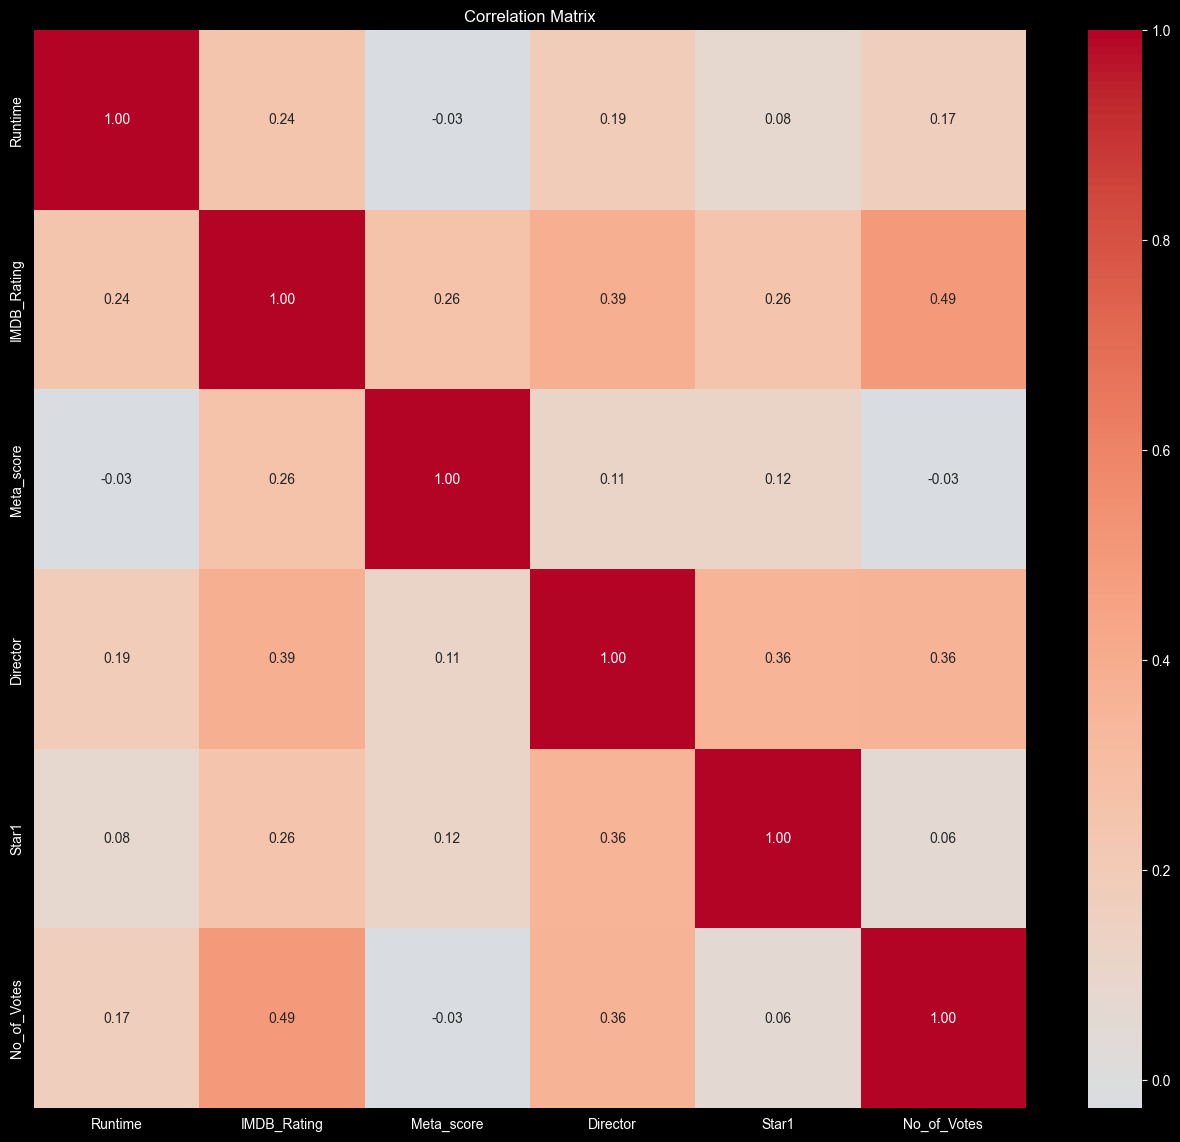

In [8]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,)

plt.title('Correlation Matrix')
plt.show()

# Part 3: Training Regression Models

In [9]:
features = ['Runtime', 'Meta_score', 'Director', 'Star1', 'No_of_Votes']
X = df[features]
y = df['IMDB_Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = {}

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    results[name] = {'RMSE': rmse, 'MAE': mae, 'R-squared': r2}
    print(f"RMSE: {rmse:.4f} ")
    print(f"MAE: {mae:.4f} ")
    print(f"R-squared: {r2:.4f}\n")

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)
evaluate_model("Linear Regression", y_test, lr_predictions)

RMSE: 0.1297 
MAE: 0.1044 
R-squared: 0.2414



In [11]:
dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)
evaluate_model("Decision Tree", y_test, dt_predictions)

RMSE: 0.1407 
MAE: 0.1091 
R-squared: 0.1078



In [12]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
evaluate_model("Random Forest", y_test, rf_predictions)

RMSE: 0.1198 
MAE: 0.0965 
R-squared: 0.3525



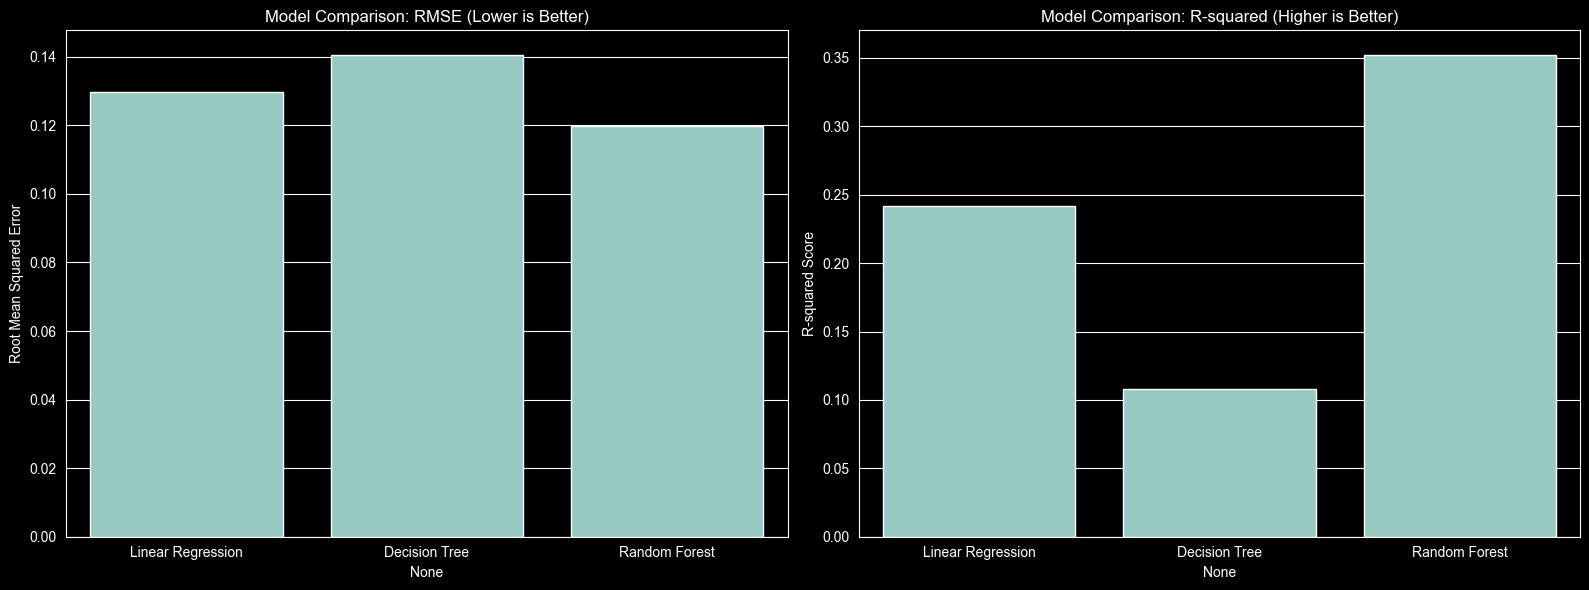

In [13]:
results_df = pd.DataFrame(results).T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=results_df.index, y=results_df['RMSE'], ax=axes[0])
axes[0].set_title('Model Comparison: RMSE (Lower is Better)')
axes[0].set_ylabel('Root Mean Squared Error')

sns.barplot(x=results_df.index, y=results_df['R-squared'], ax=axes[1])
axes[1].set_title('Model Comparison: R-squared (Higher is Better)')
axes[1].set_ylabel('R-squared Score')

plt.tight_layout()
plt.show()

# 1. Which model performed best and why?

The Random Forest Regression performed the best, achieving the lowest RMSE and highest R-squared score. Linear Regression struggled because movie ratings rarely follow strict additive linear rules. The single Decision Tree performed poorly due to its tendency to either overfit or underfit based on its depth constraints. Random Forest won because its ensemble nature captures non-linear relationships while averaging out the noise that causes single trees to fail.

# 2. Feature Importance & The Correlation Paradox
Based on our Random Forest model, No_of_Votes and Meta_score overwhelmingly drove the predictions.

No_of_Votes acts as a strong proxy for cultural impact and popularity. Highly rated movies in the Top 1000 tend to attract massive viewership, making vote count a strong predictor.

The Correlation Paradox: An interesting insight arises when comparingo ur initial correlation matrix to the Random Forest feature importance. Our correlation matrix showed Director (0.39) having a stronger linear relationship with IMDB_Rating than Meta_score (0.26). However, the Random Forest relies on Meta_score much more heavily. This perfectly highlights the difference between linear models and tree-based ensembles. Because we target-encoded Director in preprocessing (replacing names with their average ratings), we artificially forced a high linear correlation. The Random Forest, which handles non-linear, multi-variable interactions, recognized that Meta_score provides more unique variance reduction when combined with No_of_Votes, whereas the Director variable ultimately provided redundant information.

# 3. Model Limitations & Future Improvements
Even our best model's R-squared score indicates that predicting art and entertainment is highly subjective and difficult using purely numerical metadata. To improve this pipeline in the future, I would suggest:

**Hyperparameter Tuning**: We used base models for this analysis. Implementing Cross-Validation would allow us to systematically find the mathematical "sweet spot" for our Random Forest parameters (like max_depth and n_estimators) to squeeze out higher accuracy.

**Incorporating Textual Data**: The dataset contains rich textual information in the form of movie titles, genres, and plot summaries. Using Natural Language Processing (NLP) techniques to extract features from these text fields could provide additional predictive power.